In [1]:
import numpy as np
import pandas as pd 
import matplotlib as mlt
import seaborn as sns

In [2]:
df= pd.read_csv('car_price_prediction_.csv')
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   str    
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   str    
 5   Transmission  2500 non-null   str    
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   str    
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 195.4 KB


In [4]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [5]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes


Car ID            int64
Brand               str
Year              int64
Engine Size     float64
Fuel Type           str
Transmission        str
Mileage           int64
Condition           str
Price           float64
Model               str
dtype: object

In [48]:
df.groupby("Fuel Type")["Price"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Fuel Type,,,,
Diesel,655,54996.997588,5022.86,99605.33
Electric,614,51103.013534,5011.27,99982.59
Hybrid,601,52547.394759,5124.89,99905.90
Petrol,630,51767.918016,5129.96,99754.42


In [9]:
Hybrid=df['Fuel Type'][df['Fuel Type']=='Hybrid']
Hybrid.count()

np.int64(601)

In [10]:
Diesel=df['Fuel Type'][df['Fuel Type']=='Diesel']
Diesel

3       Diesel
4       Diesel
5       Diesel
10      Diesel
22      Diesel
         ...  
2485    Diesel
2486    Diesel
2493    Diesel
2498    Diesel
2499    Diesel
Name: Fuel Type, Length: 655, dtype: str

In [11]:
petrolcar=df['Fuel Type'][df['Fuel Type']=='Petrol']
petrolcar

0       Petrol
12      Petrol
19      Petrol
20      Petrol
31      Petrol
         ...  
2484    Petrol
2488    Petrol
2492    Petrol
2494    Petrol
2495    Petrol
Name: Fuel Type, Length: 630, dtype: str

In [12]:
Electriccar=df['Fuel Type'][df['Fuel Type']=='Electric']
Electriccar

1       Electric
2       Electric
6       Electric
8       Electric
9       Electric
          ...   
2474    Electric
2476    Electric
2482    Electric
2487    Electric
2489    Electric
Name: Fuel Type, Length: 614, dtype: str

In [13]:
new_df = df[['Car ID','Fuel Type', 'Price']]
new_df

,Car ID,Fuel Type,Price
0,1,Petrol,26613.92
1,2,Electric,14679.61
2,3,Electric,44402.61
3,4,Diesel,86374.33
4,5,Diesel,73577.10
...,...,...,...
2495,2496,Petrol,61384.10
2496,2497,Hybrid,24710.35
2497,2498,Hybrid,29902.45
2498,2499,Diesel,46085.67


In [14]:
max_index = new_df['Price'].idxmax()
max_value = new_df.loc[max_index, 'Price']

print(f"Index: {max_index}, Value: {max_value}")


Index: 1706, Value: 99982.59


In [15]:
max_price_P=df.loc[new_df['Fuel Type'] == 'Petrol', ['Fuel Type', 'Price']]
max_price_P

,Fuel Type,Price
0,Petrol,26613.92
12,Petrol,74766.45
19,Petrol,35735.34
20,Petrol,86382.04
31,Petrol,89587.88
...,...,...
2484,Petrol,59222.42
2488,Petrol,16102.78
2492,Petrol,66352.03
2494,Petrol,90378.98


In [16]:
print(max_price_P.max().values)
print(max_price_P['Fuel Type'].count())

['Petrol' np.float64(99754.42)]
630


In [17]:
max_price_P['Price'].mean()

np.float64(51767.918015873016)

In [18]:
max_price_D=df.loc[new_df['Fuel Type'] == 'Diesel', ['Fuel Type', 'Price']]
max_price_D.max().values
print(max_price_D.max().values)
print(max_price_D['Fuel Type'].count())
print(max_price_D['Price'].mean())
print(max_price_P['Price'].min())


['Diesel' np.float64(99605.33)]
655
54996.99758778626
5129.96


In [19]:
max_price_E=df.loc[new_df['Fuel Type'] == 'Electric', ['Fuel Type', 'Price']]
print(max_price_E.max().values)
print(max_price_E['Fuel Type'].count())
print(max_price_E['Price'].mean())
print(max_price_E['Price'].min())




['Electric' np.float64(99982.59)]
614
51103.01353420195
5011.27


In [20]:
max_price_H=df.loc[df['Fuel Type'] == 'Hybrid', ['Fuel Type', 'Price']]
print(max_price_H.max().values)
print(print(max_price_H['Fuel Type'].count()))
print(max_price_H['Price'].mean())
print(max_price_H['Price'].min())



['Hybrid' np.float64(99905.9)]
601
None
52547.39475873544
5124.89


In [21]:
brand=df.groupby('Brand').size()
brand

Brand
Audi        368
BMW         358
Ford        347
Honda       352
Mercedes    353
Tesla       348
Toyota      374
dtype: int64

In [22]:
AudiCar=df.loc[df['Brand'] == 'Audi', 'Fuel Type']
AudiCar.value_counts()

Fuel Type
Diesel      97
Petrol      96
Electric    94
Hybrid      81
Name: count, dtype: int64

In [23]:
BMWCar=df.loc[df['Brand'] == 'BMW', 'Fuel Type']
BMWCar.value_counts()

Fuel Type
Diesel      92
Electric    91
Petrol      89
Hybrid      86
Name: count, dtype: int64

In [24]:
FordCar=df.loc[df['Brand'] == 'Ford', 'Fuel Type']
FordCar.value_counts()

Fuel Type
Petrol      91
Hybrid      86
Diesel      85
Electric    85
Name: count, dtype: int64

In [25]:
HondaCar=df.loc[df['Brand'] == 'Honda', 'Fuel Type']
HondaCar.value_counts()

Fuel Type
Diesel      103
Hybrid       87
Petrol       87
Electric     75
Name: count, dtype: int64

In [26]:
MercedesCar=df.loc[df['Brand'] == 'Mercedes', 'Fuel Type']
MercedesCar.value_counts()

Fuel Type
Petrol      108
Diesel       83
Electric     82
Hybrid       80
Name: count, dtype: int64

In [27]:
TeslaCar=df.loc[df['Brand'] == 'Tesla', 'Fuel Type']
TeslaCar.value_counts()

Fuel Type
Electric    100
Diesel       88
Hybrid       85
Petrol       75
Name: count, dtype: int64

In [28]:
ToyotalCar=df.loc[df['Brand'] == 'Toyota', 'Fuel Type']
ToyotalCar.value_counts()


Fuel Type
Diesel      107
Hybrid       96
Electric     87
Petrol       84
Name: count, dtype: int64

In [29]:
df.corr(numeric_only=True)

,Car ID,Year,Engine Size,Mileage,Price
Car ID,1.000000,0.008050,0.000059,-0.035840,0.004650
Year,0.008050,1.000000,0.011833,0.002282,-0.036805
Engine Size,0.000059,0.011833,1.000000,-0.015782,-0.004420
Mileage,-0.035840,0.002282,-0.015782,1.000000,-0.008567
Price,0.004650,-0.036805,-0.004420,-0.008567,1.000000


<Axes: >

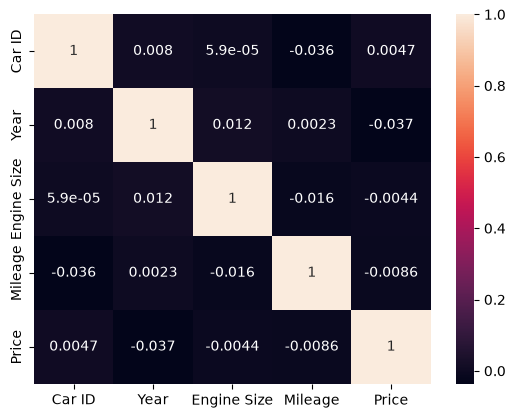

In [30]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [31]:
max_in_car=df.Brand.max()
max_in_car

'Toyota'

In [32]:
df

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


In [33]:
fuel_analysis = df.groupby('Fuel Type')['Price'].agg(
    Count='count',
    Average_Price='mean',
    Minimum_Price='min',
    Maximum_Price='max'
)

fuel_analysis

,Count,Average_Price,Minimum_Price,Maximum_Price
Fuel Type,,,,
Diesel,655,54996.997588,5022.86,99605.33
Electric,614,51103.013534,5011.27,99982.59
Hybrid,601,52547.394759,5124.89,99905.90
Petrol,630,51767.918016,5129.96,99754.42


In [34]:
brand_price = df.groupby('Brand')['Price'].agg(
    Count='count',
    Average_Price='mean',
    Minimum_Price='min',
    Maximum_Price='max'
).sort_values('Average_Price', ascending=False)

brand_price

,Count,Average_Price,Minimum_Price,Maximum_Price
Brand,,,,
BMW,358,54157.114385,5107.22,99968.62
Tesla,348,53475.547471,5343.23,99905.90
Mercedes,353,53191.090085,5353.03,99754.42
Toyota,374,52078.728235,5472.39,99400.47
Honda,352,52050.283949,5060.75,99578.74
Audi,368,51953.424810,5011.27,99982.59
Ford,347,51593.254813,5247.71,99605.33


<Axes: xlabel='Fuel Type', ylabel='count'>

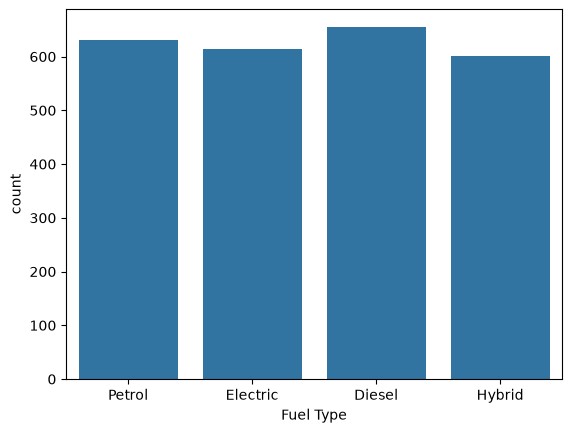

In [35]:
sns.countplot(data=df, x='Fuel Type')

<Axes: xlabel='Fuel Type', ylabel='Price'>

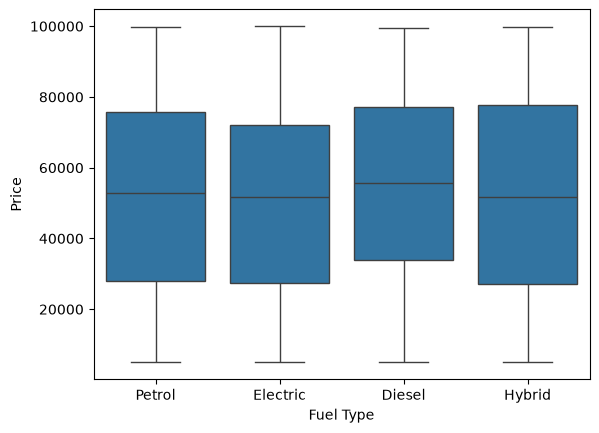

In [36]:
sns.boxplot(data=df, x='Fuel Type', y='Price')

<Axes: xlabel='Brand'>

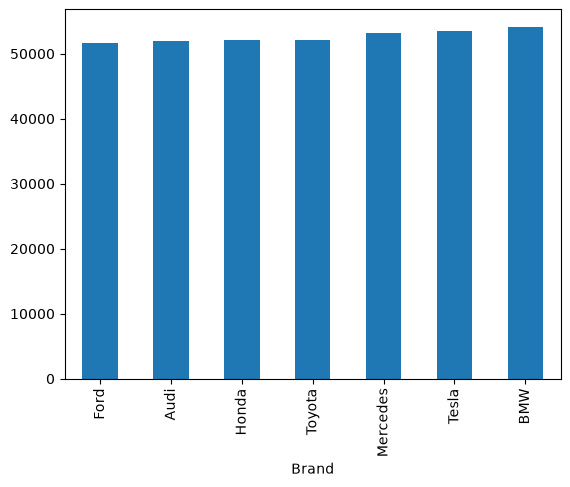

In [37]:
avg_price = df.groupby('Brand')['Price'].mean().sort_values()

avg_price.plot(kind='bar')

<Axes: xlabel='Price', ylabel='Count'>

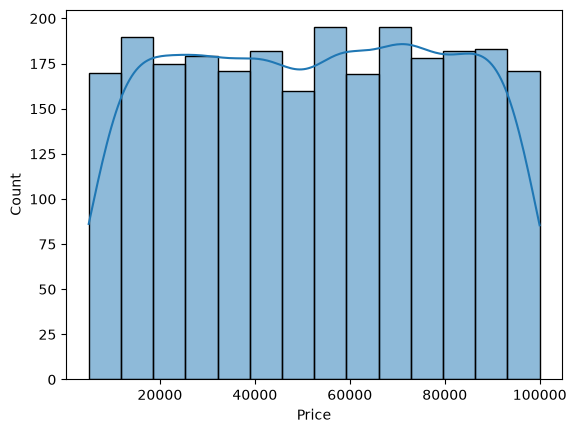

In [38]:
sns.histplot(df['Price'], kde=True)

<Axes: xlabel='Mileage', ylabel='Price'>

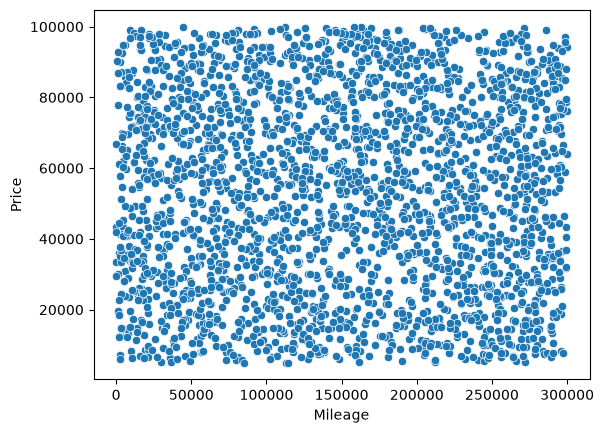

In [40]:
sns.scatterplot(data=df, x='Mileage', y='Price')

<Axes: xlabel='Engine Size', ylabel='Price'>

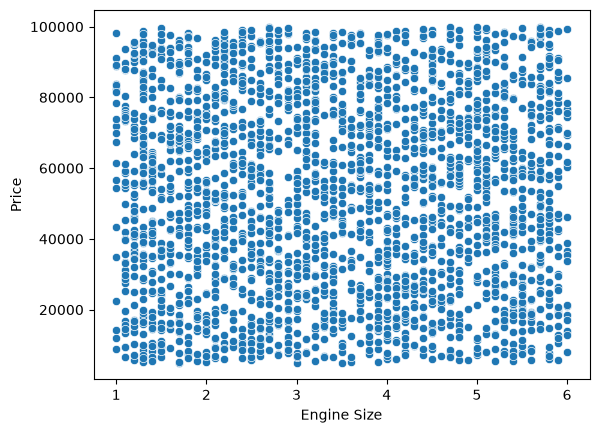

In [41]:
sns.scatterplot(data=df, x='Engine Size', y='Price')

Top 10 Most Expensive Cars

In [43]:
df.sort_values('Price', ascending=False)[
    ['Brand', 'Model', 'Year', 'Fuel Type', 'Price']
].head(10)

,Brand,Model,Year,Fuel Type,Price
1706,Audi,A3,2022,Electric,99982.59
1564,BMW,3 Series,2010,Electric,99968.62
917,Tesla,Model S,2015,Hybrid,99905.90
1763,Tesla,Model 3,2009,Hybrid,99794.46
1614,Mercedes,E-Class,2016,Petrol,99754.42
907,Ford,Focus,2000,Diesel,99605.33
2272,Honda,CR-V,2003,Diesel,99578.74
1670,Audi,A3,2009,Hybrid,99541.32
1785,Honda,Civic,2022,Hybrid,99500.97
1101,Tesla,Model S,2011,Diesel,99496.42


Cheapest Cars

In [44]:
df.sort_values('Price', ascending=True).head(10)

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
875,876,Audi,2019,3.0,Electric,Manual,112684,Used,5011.27,A4
2166,2167,Audi,2017,3.5,Diesel,Manual,114463,New,5022.86,A3
1779,1780,Honda,2003,1.7,Electric,Automatic,85366,Like New,5060.75,Accord
1803,1804,BMW,2017,1.7,Electric,Manual,161554,Used,5107.22,X5
508,509,BMW,2009,2.0,Hybrid,Automatic,212373,Like New,5124.89,3 Series
259,260,Honda,2006,3.6,Petrol,Automatic,29873,Like New,5129.96,Civic
1460,1461,Ford,2011,3.9,Hybrid,Automatic,271941,New,5247.71,Mustang
1543,1544,Tesla,2004,1.3,Hybrid,Automatic,36355,Like New,5343.23,Model Y
490,491,Mercedes,2017,1.4,Petrol,Automatic,244688,Used,5353.03,GLA
309,310,Toyota,2022,1.9,Petrol,Automatic,211284,Like New,5472.39,Prius


interesting insights

In [45]:
df.groupby(['Brand', 'Fuel Type'])['Price'].mean().sort_values(ascending=False)

Brand     Fuel Type
BMW       Diesel       59334.373587
Audi      Diesel       56574.073814
Tesla     Diesel       56368.296818
BMW       Hybrid       55599.859302
Toyota    Diesel       55101.860280
Honda     Hybrid       55014.680805
Mercedes  Diesel       54449.243494
          Electric     54237.306707
Ford      Petrol       54045.716813
Mercedes  Petrol       53719.672870
Tesla     Electric     53285.740600
Ford      Diesel       52679.123294
Toyota    Hybrid       52509.856875
Tesla     Petrol       52309.159067
Ford      Hybrid       52169.371628
Honda     Petrol       51919.030920
Tesla     Hybrid       51733.169529
Audi      Electric     51376.561170
BMW       Petrol       50992.418764
Honda     Diesel       50711.301262
BMW       Electric     50654.630879
Honda     Electric     50602.706667
Audi      Hybrid       50374.120000
Mercedes  Hybrid       50099.797125
Toyota    Electric     49961.358506
          Petrol       49928.105476
Audi      Petrol       49182.028125
Ford    